# Hotel Booking Demand Analysis

---

## Project Objective

The objective of this project is to transform hotel booking data into meaningful business insights by applying data cleaning, exploratory data analysis, and statistical techniques. The findings will help identify cancellation drivers, understand customer demand patterns, and provide recommendations that can improve hotel operations, occupancy management, and revenue planning.

---

## Business Problem

Hotels face challenges in managing booking demand due to high cancellation rates, seasonal fluctuations, and changing customer behaviour. These challenges can lead to revenue loss, inefficient room planning, and difficulties in maintaining optimal occupancy.

This project analyzes hotel booking data to identify factors influencing cancellations, understand customer booking patterns, and uncover trends in demand. The insights will support data-driven decisions to improve occupancy management, reduce cancellation risks, and enhance hotel performance.



## Business Questions

This analysis will investigate the following questions:

### Cancellation Analysis

1. What factors influence booking cancellations?
2. Does lead time affect cancellation rates?
3. Does deposit type influence cancellations?

### Customer Behaviour

4. Which customer segments generate the most bookings?
5. Which countries contribute the most guests?
6. How do special requests relate to customer behaviour?

### Demand and Performance

7. How does booking demand change over time?
8. Which hotel type performs better?
9. Which market segments provide the most valuable bookings?

---

# Dataset Understanding

In [278]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
# Load dataset
data = pd.read_csv("C:/Users/user/Documents/PYTHON/Hotel Booking/hotel_bookings_cleaned.csv", sep=";")

# Display first 5 rows
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,No Agent,No Company,0,Transient,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,No Agent,No Company,0,Transient,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,No Agent,No Company,0,Transient,75,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,No Company,0,Transient,75,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,No Company,0,Transient,98,0,1,Check-Out,2015-07-03


### Initial Dataset Observation

The first five rows show that each record represents a hotel booking. The dataset contains information about hotel type, cancellation status, booking details, customer information, stay duration, and pricing.

The data includes both numerical and categorical variables that will be explored further during the analysis.

**Note:** The dataset appears to use semicolon (`;`) separators, so the file will need to be loaded with the correct delimiter.

In [279]:
# Check number of rows and columns

data.shape

(87367, 32)

In [280]:
# Dataset structure

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 87367 entries, 0 to 87366
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   hotel                           87367 non-null  str  
 1   is_canceled                     87367 non-null  int64
 2   lead_time                       87367 non-null  int64
 3   arrival_date_year               87367 non-null  int64
 4   arrival_date_month              87367 non-null  str  
 5   arrival_date_week_number        87367 non-null  int64
 6   arrival_date_day_of_month       87367 non-null  int64
 7   stays_in_weekend_nights         87367 non-null  int64
 8   stays_in_week_nights            87367 non-null  int64
 9   adults                          87367 non-null  int64
 10  children                        87367 non-null  int64
 11  babies                          87367 non-null  int64
 12  meal                            87367 non-null  str  
 13  country     

### Dataset Overview

The cleaned dataset contains **87,367 hotel booking records** with **32 variables** describing booking details, customer information, stay characteristics, and reservation outcomes.

The dataset includes:
- **18 numerical variables** (e.g., lead time, number of guests, ADR)
- **14 categorical variables** (e.g., hotel type, country, market segment)

The data types are correctly recognized, and all columns currently contain complete values according to the initial dataset information.

In [281]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

### Variable Overview

The dataset contains variables covering different aspects of hotel bookings:

- **Booking Information:** hotel type, cancellation status, lead time, arrival dates, and reservation status.
- **Customer Information:** country, customer type, repeated guest status, and number of guests.
- **Stay Details:** weekend nights, weekday nights, meal preferences, and special requests.
- **Booking Channels:** market segment, distribution channel, agent, and company.
- **Financial Information:** average daily rate (ADR), which represents the daily cost of the booking.
- **Historical Behaviour:** previous cancellations and previous successful bookings.

These variables will be used to analyze cancellation patterns, customer behaviour, demand trends, and hotel performance.

---

# CLEAN — Data Validation

In [282]:
# Check duplicate records

data.duplicated().sum()

np.int64(0)

### Duplicate Check

The dataset contains **0 duplicate records**, indicating that each booking entry represents a unique record. No duplicate removal is required.

In [283]:
# Check missing values

data.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

### Missing Value Check

The dataset contains **0 missing values across all variables**. This confirms that the data preparation phase successfully handled missing information, and no further missing value treatment is required before analysis.

In [284]:
# Summary statistics for numerical variables

data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000,87367.000000
mean,0.274932,79.864457,2016.210365,26.839001,15.815102,1.005093,2.624893,1.875800,0.138679,0.010828,0.039088,0.030423,0.184051,0.271601,0.749814,106.374890,0.084254,0.698639
std,0.446483,86.025141,0.686122,13.674907,8.835173,1.031888,2.053468,0.626554,0.455940,0.113615,0.193805,0.369206,1.732178,0.727305,10.017384,55.020361,0.281576,0.831997
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.000000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


### Numerical Summary Observation

The descriptive statistics provide an overview of the numerical variables in the dataset. The dataset contains 87,367 records, with variables showing different scales and distributions.

Key observations:
- The average cancellation rate is approximately **27.5%**.
- The average booking lead time is around **80 days**, with values ranging from 0 to 737 days.
- The average daily rate (ADR) is approximately **106**, with some high-value bookings requiring further investigation.
- Most bookings involve around **2 adults**, with relatively few children and babies.
- Several variables, such as special requests and previous cancellations, show low average values, indicating they occur less frequently.

In [285]:
# Check unique values in categorical columns

for col in data.select_dtypes(include="str").columns:
    print(col, ":", data[col].nunique())

hotel : 2
arrival_date_month : 12
meal : 5
country : 178
market_segment : 7
distribution_channel : 5
reserved_room_type : 10
assigned_room_type : 12
deposit_type : 3
agent : 334
company : 353
customer_type : 4
reservation_status : 3
reservation_status_date : 926


### Categorical Variable Check

The dataset contains a mixture of categorical variables representing hotel details, customer characteristics, booking channels, and reservation outcomes.

Key observations:
- The dataset includes **2 hotel types**.
- Bookings come from **178 countries**, showing a diverse customer base.
- Different booking channels are represented through market segments and distribution channels.
- Variables such as agent and company contain many unique values, which may require further grouping or analysis during exploration.

---

# Exploratory Data Analysis
---
## Cancellation Behaviour

In [286]:
# Calculate cancellation percentage

data["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    72.506782
1    27.493218
Name: proportion, dtype: float64

### Booking Cancellation Overview

Most bookings were completed successfully, with 72.5% of reservations not being cancelled. However, 27.5% of bookings were cancelled, showing that cancellations are a significant factor affecting hotel demand and revenue planning.

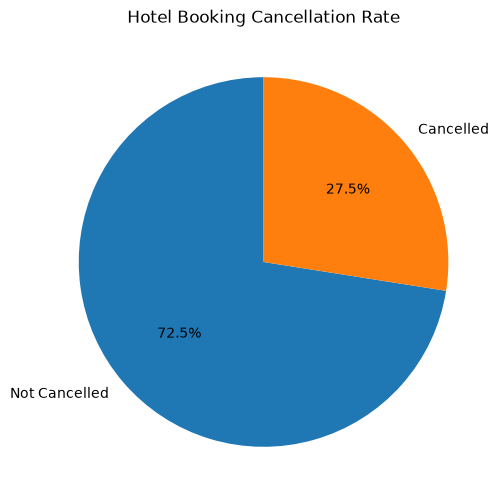

In [287]:
cancellation = data["is_canceled"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    cancellation,
    labels=["Not Cancelled", "Cancelled"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Hotel Booking Cancellation Rate")

plt.show()

## *Cancelation by hotel type*

In [288]:
hotel_cancellation_rate = data.groupby("hotel")["is_canceled"].mean() * 100

hotel_cancellation_rate

hotel
City Hotel      30.037816
Resort Hotel    23.489735
Name: is_canceled, dtype: float64

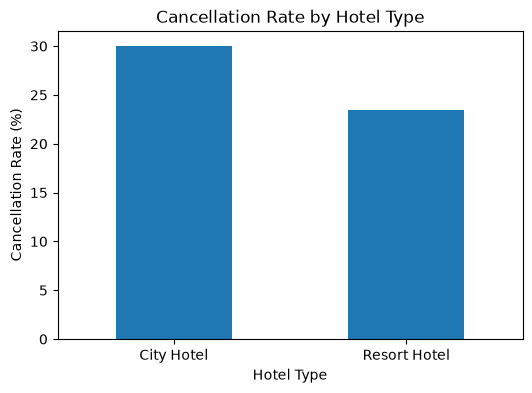

In [289]:
hotel_cancellation_rate.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.show()


### Observation

City Hotels have a higher cancellation rate (**30.0%**) compared to Resort Hotels (**23.5%**). This indicates that City Hotels experience greater booking uncertainty and may require further investigation into customer behaviour, booking channels, and market segments.

## *Does lead time influence booking cancellations?*

A longer lead time means a customer books further in advance. We want to know if customers who book earlier are more likely to cancel.

In [290]:
data.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     70.054936
1    105.734721
Name: lead_time, dtype: float64

<Figure size 700x400 with 0 Axes>

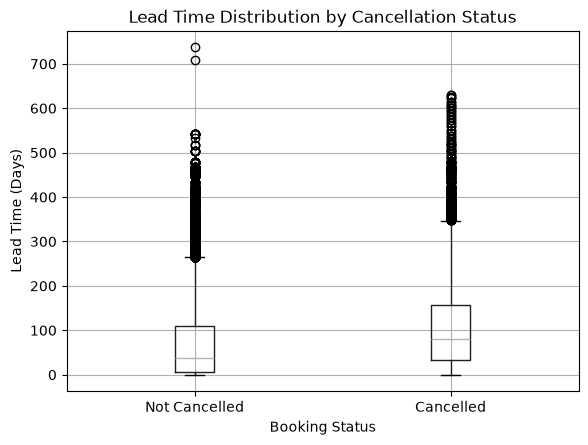

In [291]:
plt.figure(figsize=(7,4))

data.boxplot(
    column="lead_time",
    by="is_canceled"
)

plt.title("Lead Time Distribution by Cancellation Status")
plt.suptitle("")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (Days)")

plt.xticks(
    [1, 2],
    ["Not Cancelled", "Cancelled"]
)

plt.show()

### Observation

The boxplot shows that cancelled bookings generally have higher lead times compared to completed bookings. Cancelled reservations tend to be made further in advance and show greater variation in booking periods.

This suggests that customers who book earlier may have a higher chance of cancelling, possibly because they have more time to change their travel plans.

In [292]:
data.groupby("deposit_type")["is_canceled"].mean() * 100

deposit_type
No Deposit    26.688084
Non Refund    94.701349
Refundable    24.299065
Name: is_canceled, dtype: float64

### Observation

Cancellation rates vary significantly depending on the deposit type. Bookings with **Non Refund deposits have an extremely high cancellation rate (94.7%)**, compared to **No Deposit (26.7%)** and **Refundable deposits (24.3%)**.

This suggests that deposit policies are strongly related to cancellation behaviour and may influence customer commitment to a booking.

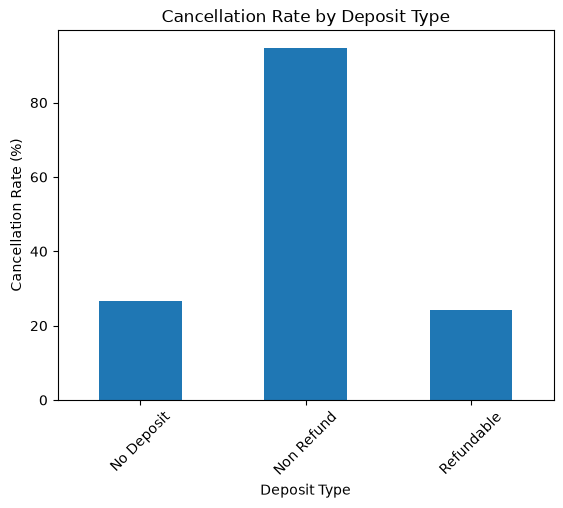

In [293]:
deposit_cancellation_rate = data.groupby("deposit_type")["is_canceled"].mean() * 100

deposit_cancellation_rate.plot(
    kind="bar"
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)

plt.show()

--- 

# Customer & Market Behaviour

### Which countries contribute the highest number of guests?

In [294]:
country_bookings = data["country"].value_counts().head(10)

country_bookings

country
PRT    27445
GBR    10423
FRA     8837
ESP     7252
DEU     5386
ITA     3066
IRL     3013
BEL     2079
BRA     1995
NLD     1910
Name: count, dtype: int64

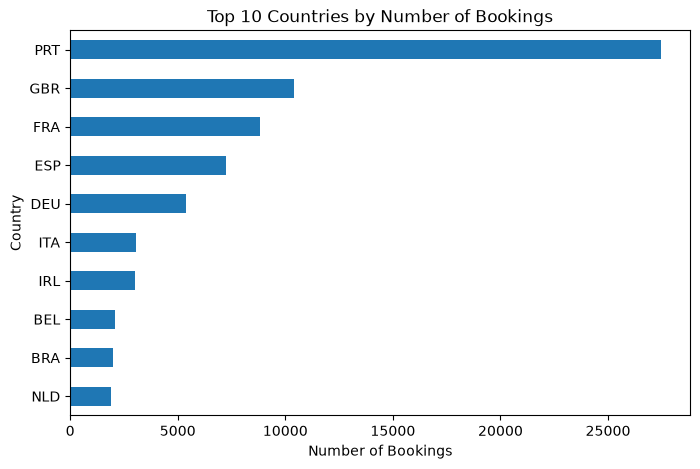

In [295]:
country_bookings.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

#### *Observation*

Portugal (PRT) contributes the highest number of hotel bookings by a large margin, followed by the United Kingdom (GBR), France (FRA), and Spain (ESP).

The customer base is mainly concentrated in European countries, indicating that these markets are important sources of hotel demand.

## Which customer segments generate the most bookings?
Business purpose:

Hotels need to understand who their customers are and which customer groups contribute the most demand

In [296]:
customer_segments = data["customer_type"].value_counts()

customer_segments

customer_type
Transient          71980
Transient-Party    11706
Contract            3137
Group                544
Name: count, dtype: int64

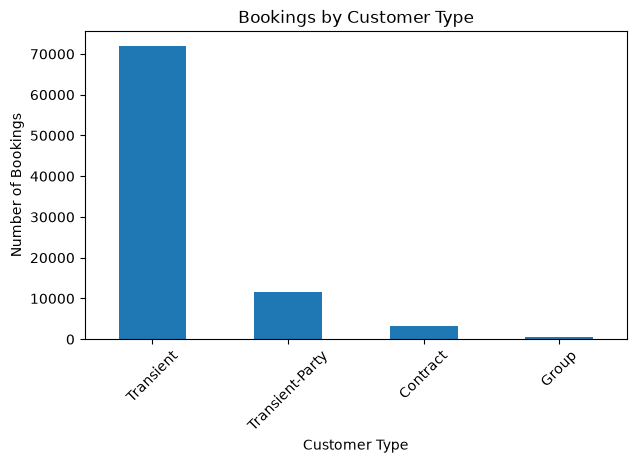

In [297]:
customer_segments.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Bookings by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

#### *Observation*

Transient customers represent the majority of hotel bookings, with significantly more reservations than other customer types. Transient-Party customers are the second largest segment, while Contract and Group bookings represent a smaller portion of demand.

## Do repeated guests behave differently from new guests?

Purpose:

Understand whether loyal customers have different booking patterns or cancellation behaviou

In [298]:
data.groupby("is_repeated_guest")["is_canceled"].mean() * 100

is_repeated_guest
0    28.300696
1     7.642753
Name: is_canceled, dtype: float64

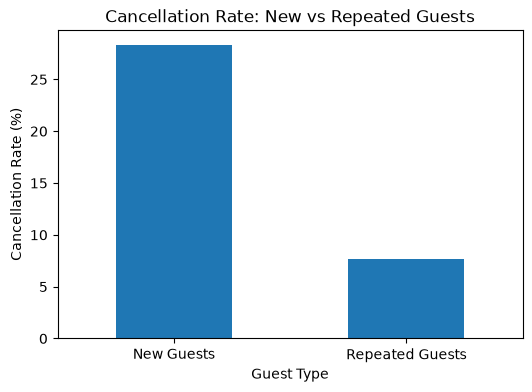

In [299]:
repeat_cancel_rate = data.groupby("is_repeated_guest")["is_canceled"].mean() * 100

repeat_cancel_rate.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Cancellation Rate: New vs Repeated Guests")
plt.xlabel("Guest Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks([0, 1], ["New Guests", "Repeated Guests"], rotation=0)

plt.show()

#### *Observation*

Repeated guests have a much lower cancellation rate (7.6%) compared to new guests (28.3%). This suggests that returning customers are more likely to follow through with their reservations, while new customers show greater cancellation behaviour.

---
# Demand Patterns

## How does booking demand change throughout the year?


In [300]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_bookings = (
    data["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

monthly_bookings

arrival_date_month
January       4691
February      6096
March         7510
April         7905
May           8351
June          7764
July         10055
August       11252
September     6685
October       6932
November      4995
December      5131
Name: count, dtype: int64

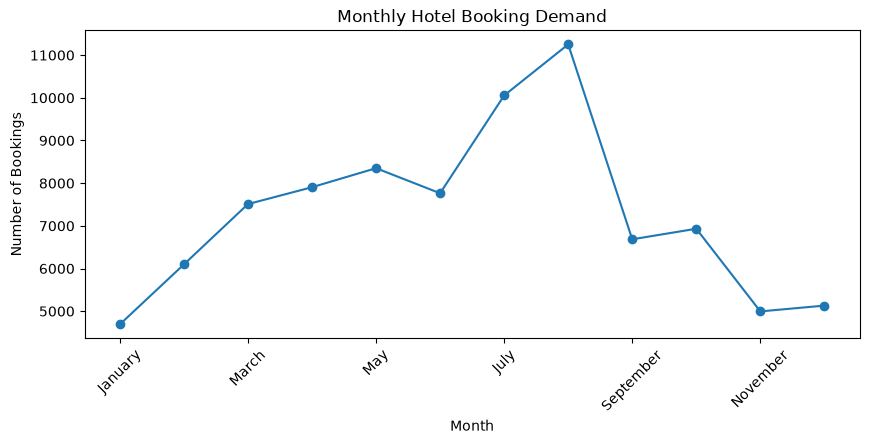

In [301]:
plt.figure(figsize=(10,4))

monthly_bookings.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Hotel Booking Demand")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

#### *Observation*

Booking demand changes throughout the year, showing a clear seasonal pattern. Demand increases from January and reaches its highest point in **August**, which recorded the most bookings. The lowest demand occurs in **January**, followed by lower booking volumes toward the end of the year.

The pattern suggests that hotels experience stronger demand during the middle of the year, particularly during the winter holiday period, while the beginning and end of the year show lower booking activity.

## Which market segments are most valuable?

In [302]:
market_adr = data.groupby("market_segment")["adr"].mean().sort_values(ascending=False)

market_adr

market_segment
Online TA        118.193242
Direct           116.638329
Aviation         100.176211
Offline TA/TO     81.810618
Groups            74.913052
Corporate         68.154394
Complementary      3.054131
Name: adr, dtype: float64

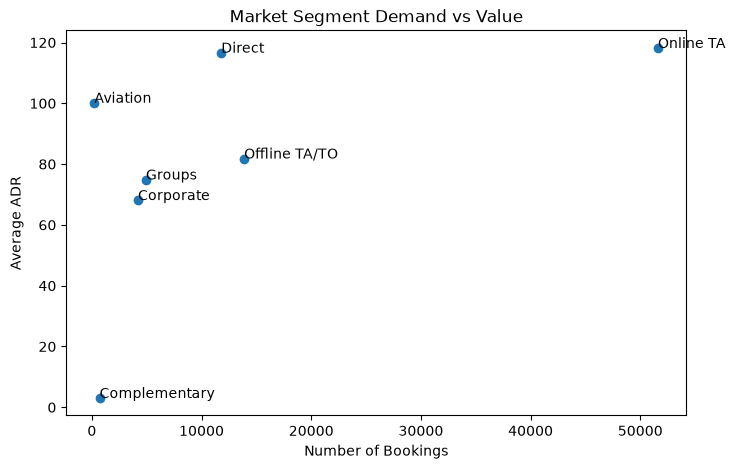

In [303]:
id="x6q7kn"
market_analysis = data.groupby("market_segment").agg(
    bookings=("market_segment", "count"),
    average_adr=("adr", "mean")
)

plt.figure(figsize=(8,5))

plt.scatter(
    market_analysis["bookings"],
    market_analysis["average_adr"]
)

for segment in market_analysis.index:
    plt.text(
        market_analysis.loc[segment, "bookings"],
        market_analysis.loc[segment, "average_adr"],
        segment
    )

plt.title("Market Segment Demand vs Value")
plt.xlabel("Number of Bookings")
plt.ylabel("Average ADR")

plt.show()

#### *Observation*

Online Travel Agents (Online TA) generate the highest number of bookings and also have one of the highest average daily rates (ADR). Direct bookings also show strong value with a similar ADR but lower booking volume.

Lower-value segments such as Corporate, Groups, and Complementary bookings have lower average ADR compared to Online TA and Direct bookings.

## How do special requests relate to customer behaviour?

In [304]:
data.groupby("total_of_special_requests")["is_canceled"].mean() * 100

total_of_special_requests
0    33.215580
1    22.404937
2    21.287045
3    17.134225
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64

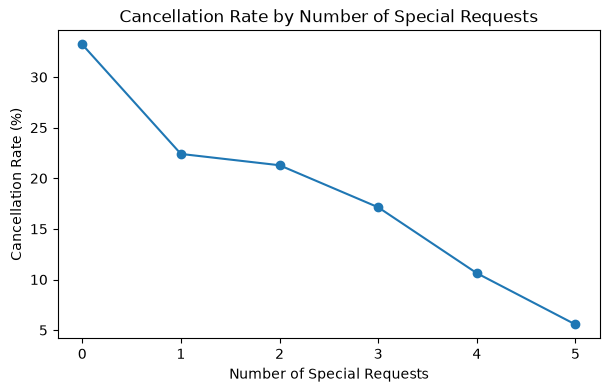

In [305]:
special_requests_cancel = (
    data.groupby("total_of_special_requests")["is_canceled"].mean() * 100
)

plt.figure(figsize=(7,4))

special_requests_cancel.plot(
    kind="line",
    marker="o"
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")

plt.show()

#### *Observation*

Cancellation rates decrease as the number of special requests increases. Guests with no special requests have the highest cancellation rate, while guests making more requests are less likely to cancel.

This suggests that customers who actively interact with the hotel before arrival may show stronger commitment to their reservations.

---

# Revenue & Booking Characteristics

## Does stay duration influence revenue and booking behaviour?

In [306]:
data["total_stay_nights"] = (
    data["stays_in_weekend_nights"] +
    data["stays_in_week_nights"]
)

data["total_stay_nights"].describe()

count    87367.000000
mean         3.629986
std          2.763238
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_stay_nights, dtype: float64

#### *Observation*

Guests typically have short stays, with an average duration of approximately **3.6 nights** and a median of **3 nights**. Most bookings fall between **2 and 5 nights**, while a small number of very long stays create extreme values.

In [307]:
data.groupby("is_canceled")["total_stay_nights"].mean()

is_canceled
0    3.486574
1    4.008201
Name: total_stay_nights, dtype: float64

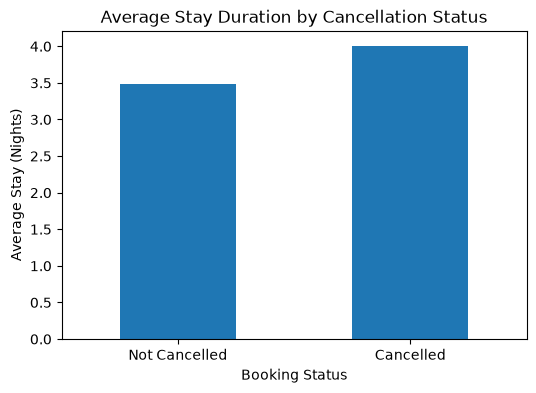

In [308]:
stay_cancel = data.groupby("is_canceled")["total_stay_nights"].mean()

plt.figure(figsize=(6,4))

stay_cancel.plot(
    kind="bar"
)

plt.title("Average Stay Duration by Cancellation Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Stay (Nights)")
plt.xticks([0,1], ["Not Cancelled", "Cancelled"], rotation=0)

plt.show()

#### *Observation*

Cancelled bookings have a slightly longer average stay duration (**4.0 nights**) compared to completed bookings (**3.5 nights**). This suggests that longer planned stays may be associated with a higher chance of cancellation, although the difference is relatively small.

## Which hotel type performs better financially?

In [309]:
# Compare hotel performance metrics
data["estimated_revenue"] = data["adr"] * data["total_stay_nights"]
hotel_performance = data.groupby("hotel").agg(
    avg_adr=("adr", "mean"),
    avg_stay=("total_stay_nights", "mean"),
    avg_revenue=("estimated_revenue", "mean")
)

hotel_performance

,avg_adr,avg_stay,avg_revenue
hotel,,,
City Hotel,111.020649,3.146436,351.489161
Resort Hotel,99.065595,4.390769,461.971164


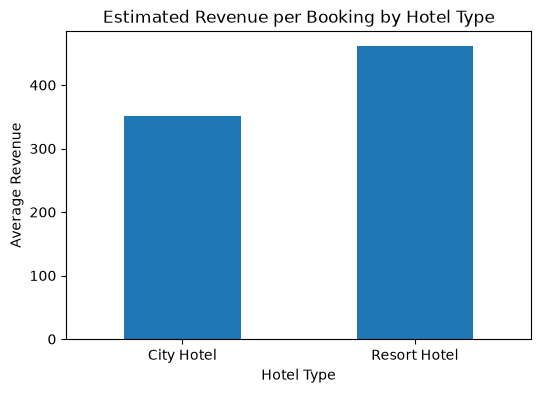

In [310]:
hotel_revenue = data.groupby("hotel")["estimated_revenue"].mean()

hotel_revenue.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Estimated Revenue per Booking by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

plt.show()

#### *Observation*

City Hotels have a higher average ADR (**111.02**) compared to Resort Hotels (**99.07**). This suggests that City Hotels generate higher revenue per night on average, although financial performance should also consider factors such as cancellation rates, occupancy, and length of stay.

Although City Hotels have a higher average ADR, Resort Hotels generate higher estimated revenue per booking due to longer average stays. Resort Hotels also have lower cancellation rates, suggesting more stable bookings.

City Hotels achieve higher revenue per night, while Resort Hotels benefit from longer customer stays and stronger booking commitment.

---

# Statistical Analysis

### Chi-square Test — Hotel Type vs Cancellation

H0: Hotel type and cancellation are independent
H1: Hotel type and cancellation are related

In [311]:

table = pd.crosstab(
    data["hotel"],
    data["is_canceled"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 446.14993667863814
p-value: 4.9659667933482075e-99
Degrees of freedom: 1


The chi-square test shows a statistically significant relationship between hotel type and cancellation behaviour (χ² = 446.15, p < 0.05).

This confirms that cancellation rates differ significantly between City Hotels and Resort Hotels. The EDA finding that City Hotels experience higher cancellation rates is statistically supported.

### Does guest loyalty influence cancellation behaviour?
H₀: Repeat guest status and cancellation status are independent.

H₁: Repeat guest status is associated with cancellation behaviour

In [312]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    data["is_repeated_guest"],
    data["is_canceled"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 701.4607672082773
p-value: 1.4389681982598199e-154
Degrees of freedom: 1


The chi-square test indicates a statistically significant relationship between repeat guest status and cancellation behaviour (χ² = 701.46, p < 0.001).

This confirms that repeat guests have significantly different cancellation behaviour compared to new guests. The EDA finding that loyal customers are less likely to cancel is statistically supported.

### Do hotel types generate different revenue per booking?

Test:
Independent two-sample t-test

Hypotheses:

H₀: The average estimated revenue per booking is the same for City Hotels and Resort Hotels.

H₁: The average estimated revenue per booking is different between the two hotel types.

In [313]:
city_revenue = data[data["hotel"] == "City Hotel"]["estimated_revenue"]

resort_revenue = data[data["hotel"] == "Resort Hotel"]["estimated_revenue"]

t_stat, p_value = ttest_ind(
    city_revenue,
    resort_revenue,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

T-statistic: -38.82779415482904
p-value: 0.0


The independent t-test shows a statistically significant difference in estimated revenue per booking between City Hotels and Resort Hotels (t = -38.83, p < 0.001).

This confirms that Resort Hotels generate significantly higher estimated revenue per booking compared to City Hotels. The difference observed during EDA is statistically supported.

---

# Statistical Analysis Summary

Three hypothesis tests were conducted to validate key findings from the exploratory analysis.

1. Hotel type and cancellation behaviour:
A chi-square test showed a significant relationship between hotel type and cancellations (χ² = 446.15, p < 0.001). City Hotels have significantly higher cancellation rates than Resort Hotels.

2. Guest loyalty and cancellation behaviour:
A chi-square test showed a significant relationship between repeat guest status and cancellations (χ² = 701.46, p < 0.001). Repeat guests are significantly less likely to cancel bookings.

3. Hotel type and revenue performance:
An independent t-test showed a significant difference in estimated revenue between hotel types (t = -38.83, p < 0.001). Resort Hotels generate higher estimated revenue per booking.

---

# SOLVE — Analysis & Findings

---

## Finding 1: Cancellation Risk Is Higher for City Hotels

### Insight

City Hotels experience higher cancellation risk compared to Resort Hotels.

### Business Meaning

Higher cancellation levels can create challenges in occupancy planning and revenue forecasting. City Hotels should focus on strategies that improve booking commitment and reduce preventable cancellations.

---

## Finding 2: Longer Lead Times Are Associated With Higher Cancellation Risk

### Insight

Bookings made further in advance are more likely to be cancelled.

### Business Meaning

Advance reservations provide planning opportunities but also introduce uncertainty. Hotels should maintain engagement with customers before arrival to increase booking commitment and reduce cancellation risk.

---

## Finding 3: Customer Loyalty Improves Booking Stability

### Insight

Repeat guests demonstrate more reliable booking behaviour compared to new customers.

### Business Meaning

Building stronger customer relationships through loyalty programs and personalized experiences can improve retention and create more predictable booking demand.

---

## Finding 4: Longer Stays Drive Higher Revenue Performance

### Insight

Revenue performance depends not only on pricing but also on customer stay duration. Resort Hotels generate stronger revenue per booking because guests tend to stay longer.

### Business Meaning

Hotels should focus on increasing booking value through longer stays, packages, and additional services rather than relying only on increasing daily rates.

---

## Finding 5: Booking Demand Follows Seasonal Patterns

### Insight

Hotel demand changes throughout the year, creating periods of higher and lower booking activity.

### Business Meaning

Hotels can improve operational planning by adjusting marketing campaigns, staffing, and pricing strategies according to seasonal demand patterns.

---

# Conclusion

This project analyzed hotel booking data to identify the factors influencing cancellations, customer behaviour, and revenue performance.

The analysis revealed that cancellation patterns are influenced by booking characteristics, hotel type, and customer loyalty. City Hotels experienced higher cancellation rates, while repeat guests showed more reliable booking behaviour. Statistical testing confirmed significant relationships between these factors and booking outcomes.

The analysis also showed that revenue performance is not determined by pricing alone. Although City Hotels had a higher average daily rate, Resort Hotels generated higher revenue per booking due to longer guest stays.

Overall, the findings highlight the importance of managing cancellation risks, improving customer retention strategies, and adapting to seasonal demand patterns to improve hotel performance and revenue stability.

---


# Recommendations

Based on the findings from the analysis, the following recommendations are proposed to improve booking stability, customer retention, and revenue performance.

---

## 1. Improve Cancellation Management

City Hotels experience higher cancellation challenges, indicating a need for stronger reservation management strategies.

Recommended actions:
- Implement booking confirmation reminders before arrival.
- Identify high-risk reservations and apply targeted engagement strategies.
- Encourage guests to commit to bookings through suitable incentives.

---

## 2. Strengthen Customer Loyalty Strategies

Repeat customers demonstrate more reliable booking behaviour, highlighting the value of customer retention.

Recommended actions:
- Develop loyalty programs for returning guests.
- Offer personalized promotions based on previous stays.
- Create incentives that encourage repeat bookings.

---

## 3. Manage Long-Lead-Time Reservations

Advance bookings provide opportunities for revenue planning but also create cancellation risk.

Recommended actions:
- Maintain communication with guests between booking and arrival.
- Send pre-arrival reminders and confirmation messages.
- Use flexible offers to increase booking commitment.

---

## 4. Maximize Revenue Through Longer Stays

Revenue performance depends not only on pricing but also on customer stay duration.

Recommended actions:
- Promote extended-stay packages.
- Create experience-based offers for resort customers.
- Encourage longer bookings during appropriate seasons.

---

## 5. Use Seasonal Demand Planning

Booking patterns change throughout the year, creating opportunities for better resource planning.

Recommended actions:
- Adjust marketing campaigns based on demand periods.
- Optimize staffing according to expected occupancy.
- Apply dynamic pricing strategies during peak seasons.

---

# Overall Recommendation

Hotels should focus on reducing preventable cancellations, increasing customer loyalty, and using demand patterns to improve operational planning and revenue generation.